In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit, brentq
from matplotlib.lines import Line2D

In [3]:
PFday = 8.64e19

scaling_laws = pd.read_csv('openai+chinchilla.csv')
scaling_laws['domain'] = scaling_laws['domain'].str.replace('_', ' ')
scaling_laws['C*'] = scaling_laws['C*'] * PFday
scaling_laws['C0'] = scaling_laws['C0'] * PFday
scaling_laws['A'] = scaling_laws['domain'].apply(lambda x: 40 if x in ['Language', 'Chinchilla'] else 5)
scaling_laws['V'] = 256
scaling_laws.loc[scaling_laws['domain'] == 'Image VQ 32x32', 'V'] = 1024
scaling_laws.loc[scaling_laws['domain'] == 'Image VQ 16x16', 'V'] = 4096
scaling_laws.loc[scaling_laws['domain'] == 'Video VQ 16x16x16', 'V'] = 4096
scaling_laws.loc[scaling_laws['domain'] == 'Language', 'V'] = 50257
scaling_laws.loc[scaling_laws['domain'] == 'Chinchilla', 'V'] = 32000
scaling_laws['ctx'] = None
scaling_laws.loc[scaling_laws['domain'] == 'Image 8x8', 'ctx'] = 3 * 8 * 8
scaling_laws.loc[scaling_laws['domain'] == 'Image 16x16', 'ctx'] = 3 * 16 * 16
scaling_laws.loc[scaling_laws['domain'] == 'Image 32x32', 'ctx'] = 3 * 32 * 32
scaling_laws.loc[scaling_laws['domain'] == 'Image VQ 16x16', 'ctx'] = 16 * 16
scaling_laws.loc[scaling_laws['domain'] == 'Image VQ 32x32', 'ctx'] = 32 * 32
scaling_laws.loc[scaling_laws['domain'] == 'Video VQ 16x16x16', 'ctx'] = 16 * 16 * 16
scaling_laws.loc[scaling_laws['domain'] == 'Language', 'ctx'] = 1024
scaling_laws.loc[scaling_laws['domain'] == 'Chinchilla', 'ctx'] = 1024

In [4]:
scaling_laws_corrected = copy.deepcopy(scaling_laws)

for _, (idx, row) in enumerate(scaling_laws.iterrows()):
    domain, gamma, delta, C0, Cstar, E = row['domain'], row['gamma'], row['delta'], row['C0'], row['C*'], row['E']
    if domain == 'Chinchilla':
        continue
    V, A, ctx = row['V'], row['A'], row['ctx']
    Cmin = 1e-6 * PFday
    Cmax = 0.1 * PFday
    log_Cs = np.linspace(np.log(Cmin), np.log(Cmax), 20)
    log_Ns = delta * (log_Cs - np.log(Cstar))
    log_Ls = -gamma * (log_Cs - np.log(C0))
    Cs = np.exp(log_Cs)
    Ls = np.exp(log_Ls) + E
    Ns = np.exp(log_Ns)
    Ns_emb = ((V + ctx) * (A / 12) ** (1/3)) * (Ns ** (1/3))
    Ns_head = (V * (A / 12) ** (1/3)) * (Ns ** (1/3))
    Ns_corrected = Ns + Ns_emb + Ns_head
    Cs_corrected = Cs * (Ns_corrected / Ns)

    def log_power_law_N(log_C, log_Cstar, delta):
        return delta * log_C - delta * log_Cstar

    def log_power_law_L(log_C, log_C0, gamma, log_E):
        log_power_part = -gamma * (log_C - log_C0)
        return np.log(np.exp(log_power_part) + np.exp(log_E))

    log_Cs_corrected = np.log(Cs_corrected)
    log_Ns_corrected = np.log(Ns_corrected)
    log_Ls_raw = np.log(Ls)

    p0_N = [np.log(Cstar), delta]
    p0_L = [np.log(C0), gamma, np.log(E) if E > 0 else np.log(1)]

    params_N, _ = curve_fit(log_power_law_N, log_Cs_corrected, log_Ns_corrected, p0=p0_N)
    log_Cstar_corrected, delta_corrected = params_N
    Cstar_corrected = np.exp(log_Cstar_corrected)

    params_L, _ = curve_fit(log_power_law_L, log_Cs_corrected, log_Ls_raw, p0=p0_L)
    log_C0_corrected, gamma_corrected, log_E_corrected = params_L
    C0_corrected = np.exp(log_C0_corrected)
    E_corrected = np.exp(log_E_corrected)

    scaling_laws_corrected.at[idx, 'C0'] = C0_corrected
    scaling_laws_corrected.at[idx, 'C*'] = Cstar_corrected
    scaling_laws_corrected.at[idx, 'gamma'] = gamma_corrected
    scaling_laws_corrected.at[idx, 'delta'] = delta_corrected
    scaling_laws_corrected.at[idx, 'E'] = E_corrected

In [5]:
df = scaling_laws_corrected

df = df[df['domain'] != 'Language']
df.loc[df['domain'] == 'Chinchilla', 'domain'] = 'Language'

df['beta'] = df['gamma'] / (1 - df['delta'])
df['alpha'] = df['gamma'] / df['delta']
df['T0'] = (df['C*'] / 6) * (df['N0']**(df['alpha'] / df['beta'])) * ((df['beta'] / df['alpha'])**(-1 / df['beta']))

order = ["Language", "Image VQ 32x32", "Image VQ 16x16", "Video VQ 16x16x16",
         "Image 32x32", "Image 16x16", "Image 8x8"]
df['domain'] = pd.Categorical(df['domain'], categories=order, ordered=True)
df = df.sort_values('domain')

/tmp/ipykernel_1623001/1815065505.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['beta'] = df['gamma'] / (1 - df['delta'])
/tmp/ipykernel_1623001/1815065505.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['alpha'] = df['gamma'] / df['delta']
/tmp/ipykernel_1623001/1815065505.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

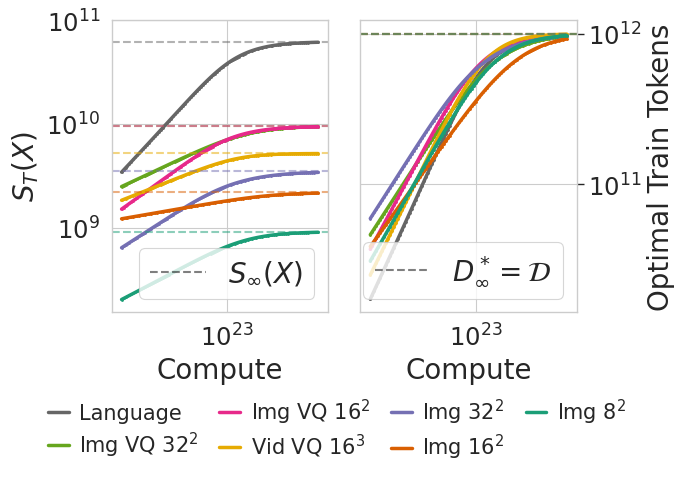

In [6]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=2)

PLOT_CONFIGS = [
    {'metric': 'S_T', 'ylabel': r'$S_T(X)$', 'asymptote_label': r'$S_\infty(X)$'},
    {'metric': 'T', 'ylabel': 'Optimal Train Tokens', 'asymptote_label': r'$D^*_\infty=\mathcal{D}$'},
]

domain_abbrev = {
    "Language":          "Language",
    "Image VQ 16x16":    "Img VQ $16^2$",
    "Image VQ 32x32":    "Img VQ $32^2$",
    "Video VQ 16x16x16": "Vid VQ $16^3$",
    "Image 32x32":       "Img $32^2$",
    "Image 16x16":       "Img $16^2$",
    "Image 8x8":         "Img $8^2$",
}

test_tokens = 1e12

def K_M_subtracted(T, beta, T0):
    return (beta / (1 - beta)) * (T0 ** beta) * (T ** (1 - beta))

def solve_T_star_for_compute(C, alpha, beta, T0, N0, test_tokens,
                             T_low=1.0, T_high_frac=0.999999):
    Dtest = test_tokens
    T_high = T_high_frac * Dtest
    def f(T):
        lhs = (T0 ** beta) * beta * (Dtest - T) * (T ** (-beta - 1))
        rhs = (3 * alpha * Dtest * (N0 ** alpha) * (2 ** alpha) *
               (C ** (-alpha)) * ((3 * T + Dtest) ** (alpha - 1)))
        return lhs - rhs
    a, b = T_low, T_high
    fa, fb = f(a), f(b)
    if np.isnan(fa) or np.isnan(fb) or np.isinf(fa) or np.isinf(fb):
        raise RuntimeError("Numerical issue at bracket endpoints.")
    if fa * fb > 0:
        Ts_scan = np.geomspace(max(T_low, 1e-12), T_high, 200)
        fs = np.array([f(t) for t in Ts_scan])
        sign = np.sign(fs)
        idx = np.where(sign[:-1] * sign[1:] < 0)[0]
        if len(idx) == 0:
            raise RuntimeError("Could not bracket root for this compute value.")
        a, b = Ts_scan[idx[0]], Ts_scan[idx[0] + 1]
    return brentq(f, a, b, maxiter=200, xtol=1e-12, rtol=1e-10)

def exact_frontier_from_compute_grid(C_grid, alpha, beta, T0, N0, E, test_tokens):
    pts = []
    for C in C_grid:
        try:
            T_star = solve_T_star_for_compute(C, alpha, beta, T0, N0, test_tokens)
            N_star = C / (2 * (3 * T_star + test_tokens))
            L = (T_star / T0) ** (-beta) + (N_star / N0) ** (-alpha) + E
            K_X_given_M = L * test_tokens
            K_M = K_M_subtracted(T_star, beta, T0)
            K_MX = K_M + K_X_given_M
            pts.append((C, K_MX, K_M, K_X_given_M, N_star, T_star))
        except RuntimeError:
            continue
    pts = np.array(pts)
    if len(pts) > 0:
        pts = pts[np.argsort(pts[:, 0])]
    return pts

n_plots = len(PLOT_CONFIGS)
fig, axes = plt.subplots(1, n_plots, figsize=(6, 4), sharex=True, squeeze=False)
axes = axes.flatten()

cmap = sns.color_palette("Dark2", n_colors=len(df)+1)
metric_map = {'K_MX': 1, 'S_T': 2, 'K_X_given_M': 3, 'N': 4, 'T': 5}

for idx, row in df.iterrows():
    domain = row['domain']
    alpha = row['alpha']
    beta = row['beta']
    T0 = row['T0']
    N0 = row['N0']
    E = row['E']
    color = cmap[idx]

    min_compute = 6 * 1e5 * 1e5 + 2 * 1e5 * test_tokens
    max_compute = 6 * 1e15 * 1e12 + 2 * 1e15 * test_tokens
    C_grid = np.geomspace(min_compute, max_compute, 500)
    pareto_points = exact_frontier_from_compute_grid(C_grid, alpha, beta, T0, N0, E, test_tokens)
    if len(pareto_points) == 0:
        continue
    if len(pareto_points) > 100:
        indices = np.unique(np.append(
            np.linspace(0, len(pareto_points) - 1, 100, dtype=int),
            len(pareto_points) - 1))
        pareto_points = pareto_points[indices]

    S_T_asymptote = K_M_subtracted(test_tokens, beta, T0)
    T_optimal = test_tokens

    for plot_idx, config in enumerate(PLOT_CONFIGS):
        ax = axes[plot_idx]
        metric_col = metric_map[config['metric']]
        ax.plot(pareto_points[:, 0], pareto_points[:, metric_col],
               c=color, linewidth=2.5, alpha=1, label=domain_abbrev[domain],
               marker='o', markersize=1)
        if config['metric'] == 'S_T':
            ax.axhline(y=S_T_asymptote, color=color, linestyle='--', linewidth=1.5, alpha=0.5)
        elif config['metric'] == 'T':
            ax.axhline(y=T_optimal, color=color, linestyle='--', linewidth=1.5, alpha=0.5)

for plot_idx, config in enumerate(PLOT_CONFIGS):
    ax = axes[plot_idx]
    ax.set_xlabel('Compute', fontsize=20)
    ax.set_ylabel(config['ylabel'], fontsize=20)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if (plot_idx % 2) == 1:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()
    if 'asymptote_label' in config:
        asymptote_line = Line2D([0], [0], color='black', linestyle='--',
                               linewidth=1.5, alpha=0.5, label=config['asymptote_label'])
        ax.legend(handles=[asymptote_line], loc='lower right', frameon=True, fontsize=20)
    if plot_idx == 0:
        ax.set_yticks([1e9, 1e10, 1e11])
    ax.minorticks_off()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', frameon=False, fontsize=15,
           ncols=4, columnspacing=1.0, handletextpad=0.5, handlelength=1.0,
           labelspacing=0.3, bbox_to_anchor=(0.5, -0.27))

plt.subplots_adjust(wspace=0.15, hspace=0.3, bottom=0.15)
plt.show()

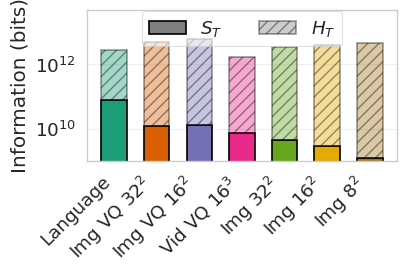

In [7]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

from matplotlib.patches import Patch

test_tokens = 1e12
C_target = 1e25

domain_abbrev = {
    "Language":          "Language",
    "Image VQ 16x16":    "Img VQ $16^2$",
    "Image VQ 32x32":    "Img VQ $32^2$",
    "Video VQ 16x16x16": "Vid VQ $16^3$",
    "Image 32x32":       "Img $32^2$",
    "Image 16x16":       "Img $16^2$",
    "Image 8x8":         "Img $8^2$",
}

decomposition_data = []

for idx, row in df.iterrows():
    domain = row['domain']
    alpha = row['alpha']
    beta = row['beta']
    T0 = row['T0']
    N0 = row['N0']
    E = row['E']

    # Solve for optimal T* and N* at the target compute
    T_star = solve_T_star_for_compute(C_target, alpha, beta, T0, N0, test_tokens)
    N_star = C_target / (2 * (3 * T_star + test_tokens))

    # Read S_T and H_T from the curve at this compute
    S_T = K_M_subtracted(T_star, beta, T0)
    L = (T_star / T0) ** (-beta) + (N_star / N0) ** (-alpha) + E
    H_T = L * test_tokens

    S_T_bits = S_T / np.log(2)
    H_T_bits = H_T / np.log(2)

    decomposition_data.append({
        'domain': domain,
        'domain_short': domain_abbrev.get(domain, domain),
        'S_T': S_T_bits,
        'H_T': H_T_bits,
        'total': S_T_bits + H_T_bits,
    })

fig, ax = plt.subplots(figsize=(4.3, 3))

cmap = sns.color_palette("Dark2", n_colors=len(df)+1)

domains = [d['domain_short'] for d in decomposition_data]
S_T_values = [d['S_T'] for d in decomposition_data]
H_T_values = [d['H_T'] for d in decomposition_data]
bar_colors = [cmap[i] for i in range(len(domains))]

x_pos = np.arange(len(domains))
bar_width = 0.6

ax.bar(x_pos, S_T_values, bar_width,
       color=bar_colors, edgecolor='black', linewidth=1.2)
ax.bar(x_pos, H_T_values, bar_width, bottom=S_T_values,
       color=bar_colors, edgecolor='black', linewidth=1.2,
       alpha=0.4, hatch='///')

ax.xaxis.grid(False)
ax.set_yscale('log')
ax.set_ylim(1e9, 5e13)
ax.set_ylabel(r'Information (bits)')
ax.set_xticks(x_pos)
ax.set_xticklabels(domains, rotation=45, ha='right')

legend_elements = [
    Patch(facecolor='gray', edgecolor='black', linewidth=1.2, label=r'$S_T$'),
    Patch(facecolor='gray', edgecolor='black', linewidth=1.2, alpha=0.4, hatch='///', label=r'$H_T$')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05),
          ncol=2, frameon=True, framealpha=0.6)

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()